### Lab and Tutorial 9 Part 1
##### Introduction to Pytorch

In [1]:
import numpy as np
#import tensorflow as tf
from matplotlib import pyplot as plt
import torch

In [2]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

In [3]:
device

'cuda'

In [4]:
a1 = torch.rand((3,4), device=device)
a2 = torch.rand((1000,200), device=device, dtype=torch.float32)
a2.device

device(type='cuda', index=0)

In [5]:
a1

tensor([[0.1952, 0.7900, 0.5640, 0.0068],
        [0.6715, 0.5199, 0.0652, 0.7880],
        [0.9010, 0.9370, 0.7597, 0.9351]], device='cuda:0')

In [16]:
a1.shape

torch.Size([3, 4])

In [6]:
a1.T

tensor([[0.1952, 0.6715, 0.9010],
        [0.7900, 0.5199, 0.9370],
        [0.5640, 0.0652, 0.7597],
        [0.0068, 0.7880, 0.9351]], device='cuda:0')

In [17]:
a1.T.shape

torch.Size([4, 3])

In [7]:
X2 = torch.linspace(-20, 20, 40, device=device)
X2.device, X2.dtype, X2.shape, X2.ndim

(device(type='cuda', index=0), torch.float32, torch.Size([40]), 1)

In [10]:
# Numpy does not accept tensors, it is cpu native
Y2 = X2.to(device='cpu').numpy()

In [15]:
Y2.shape

(40,)

In [14]:
a3 = X2.reshape((X2.shape[0],1))
a3.shape

torch.Size([40, 1])

In [19]:
a1

tensor([[0.1952, 0.7900, 0.5640, 0.0068],
        [0.6715, 0.5199, 0.0652, 0.7880],
        [0.9010, 0.9370, 0.7597, 0.9351]], device='cuda:0')

In [20]:
a1.T

tensor([[0.1952, 0.6715, 0.9010],
        [0.7900, 0.5199, 0.9370],
        [0.5640, 0.0652, 0.7597],
        [0.0068, 0.7880, 0.9351]], device='cuda:0')

In [18]:
y1 = torch.cat([a1,a1],0)
y2 = torch.cat([a1,a1],1)
y1.shape, y2.shape

(torch.Size([6, 4]), torch.Size([3, 8]))

In [21]:
y1, y2

(tensor([[0.1952, 0.7900, 0.5640, 0.0068],
         [0.6715, 0.5199, 0.0652, 0.7880],
         [0.9010, 0.9370, 0.7597, 0.9351],
         [0.1952, 0.7900, 0.5640, 0.0068],
         [0.6715, 0.5199, 0.0652, 0.7880],
         [0.9010, 0.9370, 0.7597, 0.9351]], device='cuda:0'),
 tensor([[0.1952, 0.7900, 0.5640, 0.0068, 0.1952, 0.7900, 0.5640, 0.0068],
         [0.6715, 0.5199, 0.0652, 0.7880, 0.6715, 0.5199, 0.0652, 0.7880],
         [0.9010, 0.9370, 0.7597, 0.9351, 0.9010, 0.9370, 0.7597, 0.9351]],
        device='cuda:0'))

In [22]:
W = np.linspace(-5, 5, 30).reshape((5,6))
#normal distribution with mean = 0.5 and sd = 2
x = 0.5 + np.random.randn(6,1)*2
b = np.random.randn(5,1)*1.5
y = W@x + b

In [29]:
b

array([[-0.69294361],
       [ 1.54201599],
       [ 0.01737365],
       [ 1.31358828],
       [-1.11154208]])

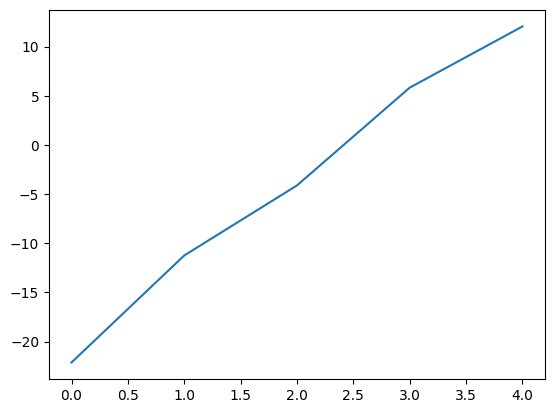

In [30]:
plt.plot(y)

In [23]:
y

array([[-22.11813948],
       [-11.2365704 ],
       [ -4.11460326],
       [  5.82822086],
       [ 12.04969998]])

In [31]:
W1 = torch.tensor(W)
x1 = torch.tensor(x)
b1 = torch.from_numpy(b)

In [32]:
b1.dtype

torch.float64

In [33]:
b1+torch.matmul(W1, x1)

tensor([[-22.1181],
        [-11.2366],
        [ -4.1146],
        [  5.8282],
        [ 12.0497]], dtype=torch.float64)

In [ ]:
# What are the differences among torch.matmul, torch.mul and torch.mm.

In [34]:
#What does the following operation do?
A = torch.randn((4,5), dtype=torch.float32, device=device)

In [35]:
L2 = torch.trace(A.T@A)

In [36]:
L2a = torch.trace(A@A.T)

In [37]:
L2==L2a

tensor(False, device='cuda:0')

In [38]:
U = np.arange(36, dtype=np.float32).reshape((3,3,4))
U

array([[[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]],

       [[12., 13., 14., 15.],
        [16., 17., 18., 19.],
        [20., 21., 22., 23.]],

       [[24., 25., 26., 27.],
        [28., 29., 30., 31.],
        [32., 33., 34., 35.]]], dtype=float32)

In [39]:
Ua = torch.from_numpy(U)

In [40]:
Ua.dtype

torch.float32

In [41]:
Ua.to(dtype=torch.float16, device=device)

tensor([[[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]],

        [[12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.]],

        [[24., 25., 26., 27.],
         [28., 29., 30., 31.],
         [32., 33., 34., 35.]]], device='cuda:0', dtype=torch.float16)

## Pytorch Overview

In [42]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

In [ ]:
training_data = datasets.FashionMNIST(
    root="data",

)